In [1]:
"""
Task : Generate the joke along with the description
Ensure, you are maintaining threads for each joke and also storing the context
"""

'\nTask : Generate the joke along with the description\nEnsure, you are maintaining threads for each joke and also storing the context\n'

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
class Joke(TypedDict):
    topic: str
    joke: str
    description: str

In [5]:
chatModel = ChatOpenAI(model_name="gpt-4o", temperature=0.7, max_tokens=100)
stroutputParser = StrOutputParser()

In [6]:
generate_joke_prompt = PromptTemplate.from_template("Generate a joke on {topic}", input = ['topic'])
explain_joke_prompt = PromptTemplate.from_template("explain the meaning of the joke {joke}", input = ['joke'])


def generate_joke(joke: Joke) -> Joke:
    topic = joke['topic']
    chain = generate_joke_prompt | chatModel | stroutputParser
    response = chain.invoke({'topic': topic})
    joke['joke'] = response
    return joke


def explain_joke(joke: Joke) -> Joke:
    input = joke['joke']
    chain = explain_joke_prompt | chatModel | stroutputParser
    response = chain.invoke({'joke': input})
    joke['description'] = response
    return joke

In [7]:
stateGraph = StateGraph(Joke)

stateGraph.add_node('generate_joke', generate_joke)
stateGraph.add_node('explain_joke', explain_joke)

stateGraph.add_edge(START, 'generate_joke')
stateGraph.add_edge('generate_joke', 'explain_joke')
stateGraph.add_edge('explain_joke', END)

checkpoint = InMemorySaver()

executable = stateGraph.compile(checkpointer=checkpoint)



In [8]:
configuration = {"configurable": {"thread_id" : 1}}

response = executable.invoke({'topic': 'apple'}, configuration)
response

{'topic': 'apple',
 'joke': 'Why did the apple stop in the middle of the road?\n\nBecause it ran out of juice! 🍏',
 'description': 'This joke is a play on words, or a pun, which is a common form of humor. The setup of the joke poses a seemingly serious question: "Why did the apple stop in the middle of the road?" The punchline, "Because it ran out of juice!" provides a humorous twist.\n\nHere\'s the breakdown:\n\n1. **Literal Interpretation**: The joke suggests that an apple is moving along the road and then stops because it "runs out of juice." This personification of the apple'}

In [9]:
# Getting the info about the state

executable.get_state(configuration)

StateSnapshot(values={'topic': 'apple', 'joke': 'Why did the apple stop in the middle of the road?\n\nBecause it ran out of juice! 🍏', 'description': 'This joke is a play on words, or a pun, which is a common form of humor. The setup of the joke poses a seemingly serious question: "Why did the apple stop in the middle of the road?" The punchline, "Because it ran out of juice!" provides a humorous twist.\n\nHere\'s the breakdown:\n\n1. **Literal Interpretation**: The joke suggests that an apple is moving along the road and then stops because it "runs out of juice." This personification of the apple'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193eca-b717-66b2-8002-e79cfe60a033'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-09T12:20:12.310051+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193eca-9b91-6e7e-8001-b6eac91c10c5'}}, tasks=(), interrupts=())

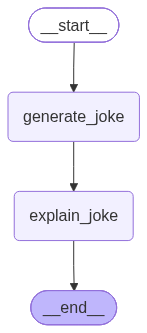

In [10]:
executable

In [11]:
# get detailed state info

history = executable.get_state_history(configuration) # returns a generator object.

for record in history:
    print(record)


StateSnapshot(values={'topic': 'apple', 'joke': 'Why did the apple stop in the middle of the road?\n\nBecause it ran out of juice! 🍏', 'description': 'This joke is a play on words, or a pun, which is a common form of humor. The setup of the joke poses a seemingly serious question: "Why did the apple stop in the middle of the road?" The punchline, "Because it ran out of juice!" provides a humorous twist.\n\nHere\'s the breakdown:\n\n1. **Literal Interpretation**: The joke suggests that an apple is moving along the road and then stops because it "runs out of juice." This personification of the apple'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193eca-b717-66b2-8002-e79cfe60a033'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-09T12:20:12.310051+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f193eca-9b91-6e7e-8001-b6eac91c10c5'}}, tasks=(), interrupts=())
Sta

In [12]:
#### Time Travel
configuration_old = {"configurable": {"thread_id" : 1, 'checkpoint_id': '1f192715-a001-67c4-bfff-4d4d43108b14'}}

oldCheckpoint = executable.get_state_history(configuration_old)

for record in oldCheckpoint:
    print(record)

In [14]:
# to rerun from an old check point
"""
Before running this, pass correct checkpoint_id in the configuration_old 
"""
executable.invoke(None, configuration_old) 

EmptyInputError: Received no input for __start__

In [ ]:
# updating the state
# Task: change the state and re-run the workflow
configuration_old_first = {"configurable": {"thread_id" : '1', 'checkpoint_ns': '', 'checkpoint_id': '1f192715-a001-67c4-bfff-4d4d43108b14'}} # checkpoint: 1 , as in the state i am just passing topic
newState ={'topic' : 'banana'}

executable.update_state(configuration_old_first, newState)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19271a-7b0f-6a1a-8000-92b48979bc64'}}

In [ ]:
history = executable.get_state_history(configuration) # returns a generator object.

for record in history:
    print(record)

StateSnapshot(values={'topic': 'apple', 'joke': 'Why did the apple stop in the middle of the road?\n\nBecause it ran out of juice! 🍏', 'description': 'This joke is a classic example of a pun, which is a form of wordplay that exploits the multiple meanings of a word or phrase for humorous effect. \n\nIn this joke, the humor comes from the double meaning of the word "juice." The setup of the joke describes an apple stopping in the middle of the road, suggesting something unusual or unexpected because apples don\'t actually move on their own. The punchline, "Because it ran out of juice," plays on two interpretations of "juice":\n\n1'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19271d-907e-6cae-8003-9a77a122039f'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-07T15:08:29.533041+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19271d-7ded-6324-8002-a26544445f12

In [ ]:
configuration_latest = {"configurable": {"thread_id" : '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19271a-7b0f-6a1a-8000-92b48979bc64'}} # checkpoint: 1 , as in the state i am just passing topic

executable.invoke(None, configuration_latest)

{'topic': 'banana',
 'joke': "Why did the banana go to the doctor?\n\nBecause it wasn't peeling well! 🍌",
 'description': 'The joke "Why did the banana go to the doctor? Because it wasn\'t peeling well!" is a classic example of a pun, which is a form of wordplay that exploits multiple meanings of a term or similar-sounding words for humorous effect. \n\nIn this joke, the humor arises from the double meaning of the word "peeling." In one sense, "peeling" refers to the banana\'s skin, which is a literal interpretation. If a banana isn\'t "peeling well," it might'}

In [ ]:
history = executable.get_state_history(configuration) # returns a generator object.
for record in history:
    print(record)

StateSnapshot(values={'topic': 'banana', 'joke': "Why did the banana go to the doctor?\n\nBecause it wasn't peeling well! 🍌", 'description': 'The joke "Why did the banana go to the doctor? Because it wasn\'t peeling well!" is a classic example of a pun, which is a form of wordplay that exploits multiple meanings of a term or similar-sounding words for humorous effect. \n\nIn this joke, the humor arises from the double meaning of the word "peeling." In one sense, "peeling" refers to the banana\'s skin, which is a literal interpretation. If a banana isn\'t "peeling well," it might'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19271e-c92f-6764-8002-2e8cfc7f7687'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-07T15:09:02.320988+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19271e-b234-6afa-8001-08dadfdb7188'}}, tasks=(), interrupts=())
StateSnapshot(values={